In [8]:
import pandas as pd

df = pd.read_csv("Online_Retail.csv")

print("Dataset loaded successfully!")
print("Number of rows and columns:", df.shape)

df.head()

Dataset loaded successfully!
Number of rows and columns: (12914, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6.0,12/1/10 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6.0,12/1/10 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8.0,12/1/10 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6.0,12/1/10 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6.0,12/1/10 8:26,3.39,17850.0,United Kingdom


In [7]:
df.shape

(12914, 8)

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12914 entries, 0 to 12913
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   InvoiceNo    12914 non-null  str    
 1   StockCode    12914 non-null  str    
 2   Description  12869 non-null  str    
 3   Quantity     12913 non-null  float64
 4   InvoiceDate  12913 non-null  str    
 5   UnitPrice    12913 non-null  float64
 6   CustomerID   9408 non-null   float64
 7   Country      12913 non-null  str    
dtypes: float64(3), str(5)
memory usage: 807.3 KB


In [10]:
df.isnull().sum()

InvoiceNo         0
StockCode         0
Description      45
Quantity          1
InvoiceDate       1
UnitPrice         1
CustomerID     3506
Country           1
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(247)

In [12]:
# Remove duplicate rows
df = df.drop_duplicates()

# Remove rows missing important customer/transaction information
df = df.dropna(
    subset=["CustomerID", "InvoiceDate", "Quantity", "UnitPrice"]
)

# Remove returns/cancelled transactions
df = df[df["Quantity"] > 0]

# Remove transactions with zero price
df = df[df["UnitPrice"] > 0]

print("Cleaned dataset shape:", df.shape)

Cleaned dataset shape: (9049, 8)


In [13]:
df["InvoiceDate"] = pd.to_datetime(
    df["InvoiceDate"],
    format="%m/%d/%y %H:%M"
)

In [14]:
df["PurchaseValue"] = df["Quantity"] * df["UnitPrice"]

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,PurchaseValue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6.0,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6.0,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8.0,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6.0,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6.0,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [16]:
reference_date = df["InvoiceDate"].max()

print("Reference date:", reference_date)

Reference date: 2010-12-06 14:36:00


In [17]:
rfm = df.groupby("CustomerID").agg(
    Recency=("InvoiceDate", lambda x: (reference_date - x.max()).days),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("PurchaseValue", "sum")
)

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12395.0,2,1,346.10
12427.0,3,1,303.50
12431.0,5,1,358.25
12433.0,5,1,1919.14
12472.0,1,1,1631.30


In [18]:
rfm.describe()


,Recency,Frequency,Monetary
count,360.000000,360.000000,360.000000
mean,2.488889,1.319444,483.714361
std,1.822144,1.897267,832.872234
min,0.000000,1.000000,15.000000
25%,1.000000,1.000000,184.400000
50%,3.000000,1.000000,298.960000
75%,4.000000,1.000000,421.255000
max,5.000000,34.000000,9407.340000


In [19]:
print("Number of customers:", rfm.shape[0])

Number of customers: 360


In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(
    rfm[["Recency", "Frequency", "Monetary"]]
)

print("Scaled data shape:", rfm_scaled.shape)

Scaled data shape: (360, 3)


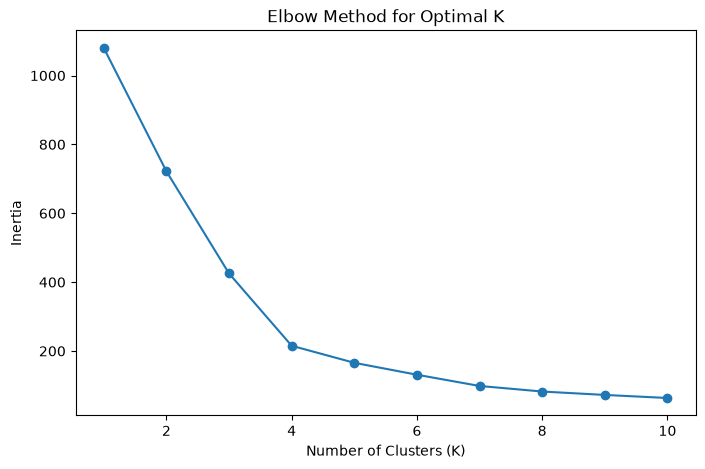

In [21]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), inertia, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")
plt.show()


### Elbow Method Observation

The inertia decreases sharply as the number of clusters increases, then begins to level off around K = 3. This suggests that 3 clusters provide a suitable balance between reducing within-cluster variation and maintaining meaningful customer segments. Therefore, K = 3 was selected for the K-Means clustering analysis.

In [22]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

rfm.head()


,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12395.0,2,1,346.10,1
12427.0,3,1,303.50,0
12431.0,5,1,358.25,0
12433.0,5,1,1919.14,0
12472.0,1,1,1631.30,1


In [23]:
rfm["Cluster"].value_counts().sort_index()


Cluster
0    204
1    150
2      6
Name: count, dtype: int64

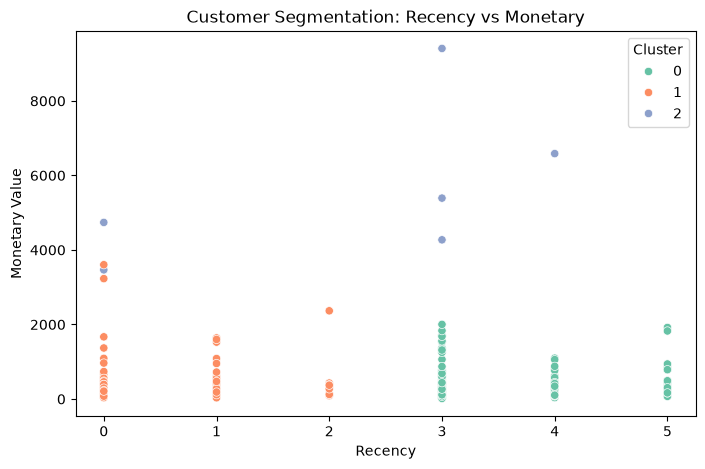

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=rfm,
    x="Recency",
    y="Monetary",
    hue="Cluster",
    palette="Set2"
)

plt.title("Customer Segmentation: Recency vs Monetary")
plt.xlabel("Recency")
plt.ylabel("Monetary Value")
plt.show()

### Observation: Monetary Value vs Recency

The scatter plot shows the distribution of customers based on their monetary value and recency. The clusters reveal differences in spending and how recently customers made purchases, demonstrating that these two RFM measures help distinguish customers with different purchasing behaviours.

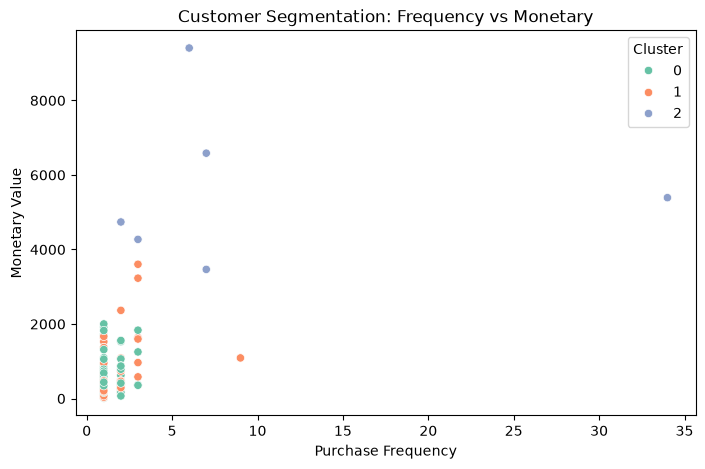

In [25]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=rfm,
    x="Frequency",
    y="Monetary",
    hue="Cluster",
    palette="Set2"
)

plt.title("Customer Segmentation: Frequency vs Monetary")
plt.xlabel("Purchase Frequency")
plt.ylabel("Monetary Value")
plt.show()

### Observation: Monetary Value vs Purchase Frequency

The scatter plot shows how customer spending varies with purchase frequency across the three clusters. Customers with higher purchase frequency generally show differences in monetary value, indicating that purchasing frequency is an important factor in distinguishing customer segments.

In [27]:
cluster_profile = rfm.groupby("Cluster")[
    ["Recency", "Frequency", "Monetary"]
].mean().round(2)

cluster_profile

,Recency,Frequency,Monetary
Cluster,,,
0,3.92,1.12,382.27
1,0.55,1.25,415.29
2,2.17,9.83,5643.30


## Cluster Profiling

The clusters were profiled using the average Recency, Frequency, and Monetary values to understand the purchasing behaviour of each customer segment.

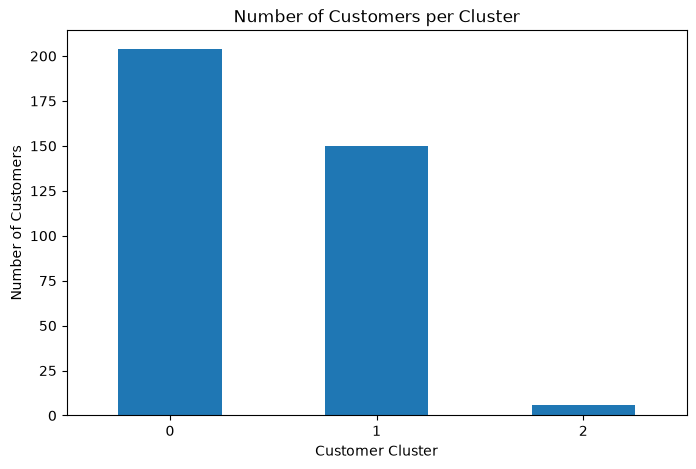

In [28]:
import matplotlib.pyplot as plt

cluster_counts = rfm["Cluster"].value_counts().sort_index()

plt.figure(figsize=(8, 5))
cluster_counts.plot(kind="bar")

plt.title("Number of Customers per Cluster")
plt.xlabel("Customer Cluster")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)

plt.show()

### Observation: Customer Distribution by Cluster

The bar chart shows the distribution of customers across the three identified clusters. The size of each cluster varies, indicating that customers are not evenly distributed across the different purchasing behaviour segments.

In [29]:
cluster_profile

,Recency,Frequency,Monetary
Cluster,,,
0,3.92,1.12,382.27
1,0.55,1.25,415.29
2,2.17,9.83,5643.30


## Insights & Marketing Recommendations

### Cluster 0 — Customer Segment
Customers in this segment show a particular pattern of recency, purchase frequency, and monetary value. Marketing efforts should focus on maintaining engagement and encouraging repeat purchases.

### Cluster 1 — Customer Segment
This segment represents customers with a different level of purchasing activity and spending. Personalised promotions and product recommendations can be used to increase their purchase frequency and customer value.

### Cluster 2 — Customer Segment
Customers in this segment show another distinct purchasing pattern. Targeted re-engagement campaigns and special offers can help strengthen their relationship with the business.